#### PRUEBAS MODELO CLASIFICACIÓN TIPO DE TAREA 

In [1]:
import pandas   as pd
import numpy    as np   
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../synthetic_data/synthetic_example.csv')

In [3]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time
0,Wade Inc,Against Redesign – Violet,10/06/2020,Complete,William Villarreal,New Item,Urgent,Build a new section in section 'FAQ block'. Ne...,Tablet,Safari,https://www.againstredesign–violet.com,5,4
1,Conrad-Jenkins,Summer Portal – LightSalmon,19/05/2021,Complete,Elizabeth Mccoy,Requested Change,High,"Hey team, this is Elizabeth Mccoy from Conrad-...",Mobile,Safari,https://www.summerportal–lightsalmon.com,5,4
2,"Cook, Brandt and Holden",Discuss Dashboard – CornflowerBlue,23/04/2024,Complete,Anthony Sheppard,Requested Change,High,"Hi, this is about the Discuss Dashboard – Corn...",Mobile,Safari,https://www.discussdashboard–cornflowerblue.com,3,3
3,Parks LLC,Already Dashboard – AntiqueWhite,13/03/2020,Complete,Allison Johnson,Requested Change,Normal,"Hey team, this is Allison Johnson from Parks L...",Mobile,Chrome,https://www.alreadydashboard–antiquewhite.com,3,3
4,Conrad-Jenkins,Production Campaign – Blue,28/07/2022,Complete,Tanya Swanson,Design Issues,Normal,Design problem found in the footer. This shoul...,Desktop,Chrome,https://www.productioncampaign–blue.com,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Stewart PLC,Investment Landing – SpringGreen,15/04/2021,Complete,Jacob Edwards,New Item,Normal,New component needed in section 'footer'. Cons...,Desktop,Samsung Internet,https://www.investmentlanding–springgreen.com,5,5
9996,Bruce Inc,Return Dashboard – SpringGreen,30/01/2024,Complete,Dr. Mark Hale,Requested Change,High,"Dr. Mark Hale from Bruce Inc, reporting an iss...",Desktop,Chrome,https://www.returndashboard–springgreen.com,8,13
9997,"Mack, Smith and Ingram",Sort Platform – Wheat,24/12/2021,Complete,William Colon,Design Issues,Normal,Improve visual design in the pricing table. Ha...,Tablet,Safari,https://www.sortplatform–wheat.com,3,3
9998,Tran-Lewis,These Landing – RoyalBlue,18/05/2022,Complete,Philip Bryant,Requested Change,High,Hi! Philip Bryant here (from Tran-Lewis) Updat...,Mobile,Chrome,https://www.theselanding–royalblue.com,3,1


In [4]:
# MINI EDA DEL REQUEST TYPE
df['Request Type'].value_counts()


Request Type
New Item            2533
Requested Change    2526
Design Issues       2481
Copy Revision       2460
Name: count, dtype: int64

<Axes: xlabel='Request Type', ylabel='count'>

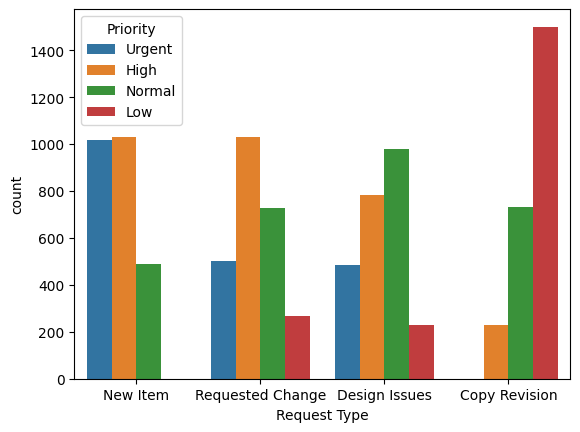

In [5]:
## VER LA CORRELACIÓN ENTRE rquest type y priority
sns.countplot(data=df, x='Request Type', hue='Priority')

c:\Users\nagor\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


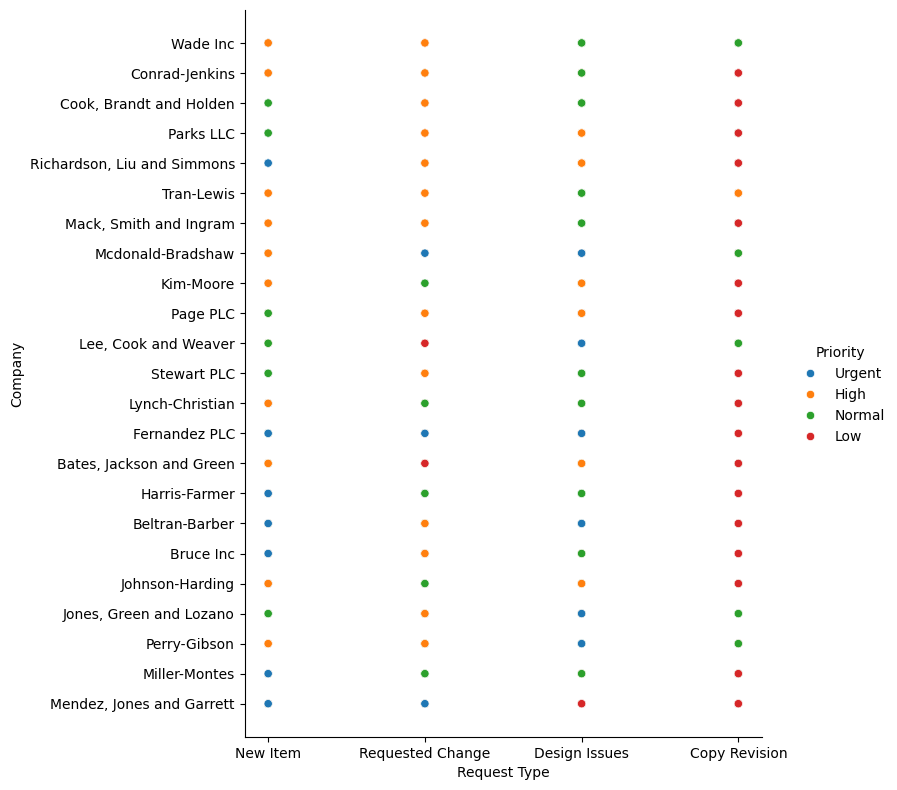

In [6]:
# correlacion entre Request Type y Company
sns.pairplot(data=df, x_vars='Request Type', y_vars='Company', hue='Priority', size=8)

<Axes: xlabel='Device'>

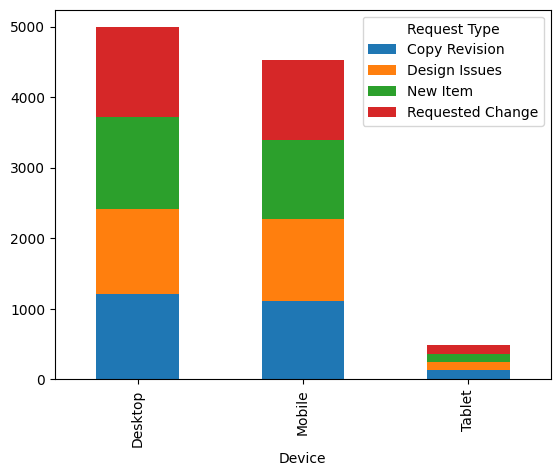

In [7]:
# correlacion entre Request Type y el Device

pd.crosstab(df['Device'], df['Request Type']).plot(kind='bar', stacked=True)

<Axes: xlabel='Request Type', ylabel='Browser'>

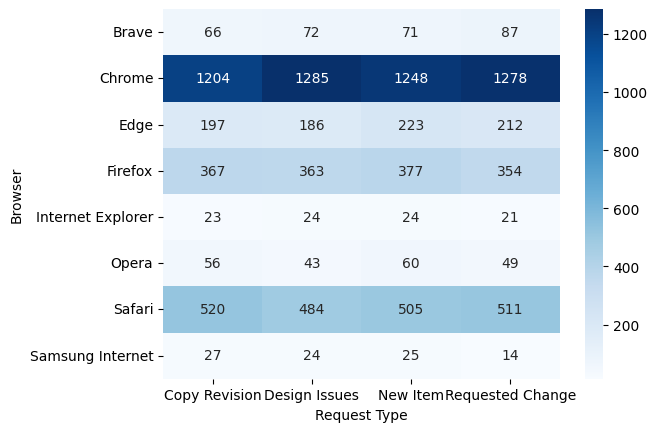

In [8]:
pivot = pd.crosstab(df['Browser'], df['Request Type'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')

<Axes: xlabel='Month'>

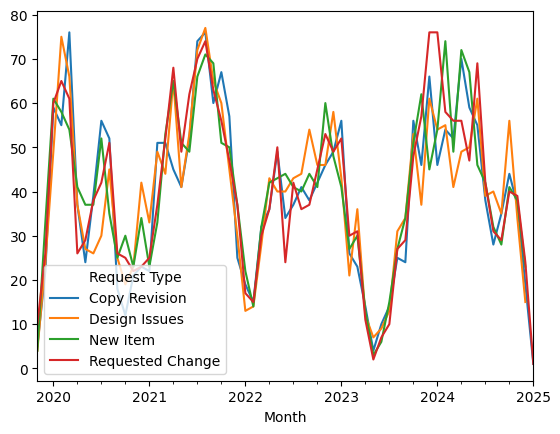

In [9]:
#series detiemp agrupadas por mes y año

df['Input Date'] = pd.to_datetime(df['Input Date'], dayfirst=True)
df['Month'] = df['Input Date'].dt.to_period('M')
df.groupby(['Month', 'Request Type']).size().unstack().plot()


<Axes: xlabel='Request Type', ylabel='Real Time'>

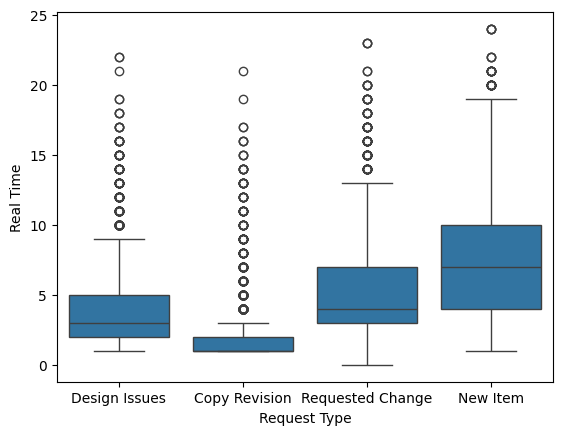

In [10]:
# ¿Qué tipo de solicitud tiende a tardar más o menos que lo estimado?
import seaborn as sns
sns.boxplot(x='Request Type', y='Real Time', data=df)

In [11]:
# para ver quién hace más solicitudesde cada tipo
top_requesters = df.groupby(['Request Type', 'Requester']).size().reset_index(name='Count')
top_requesters = top_requesters.sort_values(['Request Type', 'Count'], ascending=[True, False])


In [12]:
top_requesters

,Request Type,Requester,Count
1115,Copy Revision,Jessica Jones,4
2028,Copy Revision,Robert Williams,3
331,Copy Revision,Brian White,2
422,Copy Revision,Charles Johnson,2
451,Copy Revision,Christina Wilson,2
...,...,...,...
9801,Requested Change,Zachary Jackson,1
9802,Requested Change,Zachary Levy,1
9803,Requested Change,Zachary Page,1
9804,Requested Change,Zachary Sawyer,1


In [13]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time,Month
0,"Henderson, Riggs and Hoffman",Bank Platform – MediumBlue,2022-01-18,Complete,Jason Garcia,Design Issues,Normal,"Heads up! Jason Garcia from Henderson, Riggs a...",Desktop,Safari,https://www.bankplatform–mediumblue.com,2,2,2022-01
1,Johnson and Sons,Large Platform – DarkKhaki,2023-03-21,Complete,Amy Barron,Copy Revision,Low,Reporting a detail in Large Platform – DarkKha...,Desktop,Brave,https://www.largeplatform–darkkhaki.com,5,7,2023-03
2,"Smith, Robinson and Taylor",Learn Campaign – Cyan,2020-02-25,Complete,Henry Miller DVM,Requested Change,Urgent,"Hi there! Henry Miller DVM from Smith, Robinso...",Mobile,Firefox,https://www.learncampaign–cyan.com,13,13,2020-02
3,Bell LLC,National Campaign – MediumSpringGreen,2022-05-24,Complete,Tina Simmons,Requested Change,High,Reporting a detail in National Campaign – Medi...,Desktop,Chrome,https://www.nationalcampaign–mediumspringgreen...,3,2,2022-05
4,"Hall, Garcia and Davis",Local Redesign – FloralWhite,2024-03-15,Complete,Daniel Cooper,Requested Change,Normal,"Hi there! Daniel Cooper from Hall, Garcia and ...",Tablet,Firefox,https://www.localredesign–floralwhite.com,3,3,2024-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Johnson and Sons,Together Campaign – HotPink,2020-04-13,Complete,Barbara Martin,Copy Revision,Normal,Hi there! Barbara Martin from Johnson and Sons...,Desktop,Opera,https://www.togethercampaign–hotpink.com,1,1,2020-04
9996,Johnson and Sons,Some Campaign – Violet,2024-06-09,Complete,Marissa Salinas,Copy Revision,Low,Rewriting needed for the main of pricing table...,Mobile,Chrome,https://www.somecampaign–violet.com,1,1,2024-06
9997,"Reyes, Carter and Collier",Price Portal – LightBlue,2020-01-18,Complete,Kayla Ayers,Requested Change,High,"Heads up! Kayla Ayers from Reyes, Carter and C...",Mobile,Chrome,https://www.priceportal–lightblue.com,8,6,2020-01
9998,Dillon-Weber,Democrat Portal – Purple,2023-08-08,Complete,Mark Sims,Copy Revision,Low,Please revise the copy in section 'main of hea...,Mobile,Safari,https://www.democratportal–purple.com,3,3,2023-08


In [14]:
# dividir train test split
from sklearn.model_selection import train_test_split
X = df['Request']
y = df['Request Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Pasos generales:**

Vectorización del texto (Request) – transformar el texto a una representación numérica (bag-of-words o TF-IDF).

Entrenamiento de un modelo de clasificación – por ejemplo, LogisticRegression, RandomForest, MultinomialNB, etc.

Evaluación del modelo – precisión, matriz de confusión, etc

In [15]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Preprocesar de forma automática el idioma usando un modelo multilingüe
# Usaremos un vectorizador simple y probaremos con un clasificador
# En lugar de 'stop_words="english"' y 'stop_words="spanish"', podemos optar por un solo modelo

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),  # Usamos TF-IDF sin especificar idioma para que capture ambos
    ('clf', LogisticRegression(max_iter=1000))  # Clasificador
])

# Entrenamiento
pipeline.fit(X_train, y_train)

# Evaluación
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


                  precision    recall  f1-score   support

   Copy Revision       0.89      0.92      0.90       489
   Design Issues       0.78      0.82      0.80       498
        New Item       0.80      0.84      0.82       491
Requested Change       0.89      0.78      0.83       522

        accuracy                           0.84      2000
       macro avg       0.84      0.84      0.84      2000
    weighted avg       0.84      0.84      0.84      2000



In [16]:
request_ejemplo = "Please update the homepage banner to reflect the new campaign launch."


prediction = pipeline.predict([request_ejemplo])
print(f"Request: {request_ejemplo}")
print(f"Predicted Request Type: {prediction[0]}")


Request: Please update the homepage banner to reflect the new campaign launch.
Predicted Request Type: New Item


In [18]:
request_2 = "There is a typo in the About Us section that needs correction."

prediction = pipeline.predict([request_2])
print(f"Request: {request_2}")
print(f"Predicted Request Type: {prediction[0]}")

Request: There is a typo in the About Us section that needs correction.
Predicted Request Type: Copy Revision


In [30]:
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Codificar etiquetas categóricas a números
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Crear pipeline
pipeline_xgb = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('xgb', XGBClassifier())
])

# Entrenar con etiquetas codificadas
pipeline_xgb.fit(X_train, y_train_encoded)

# Predecir con etiquetas codificadas
y_pred_encoded = pipeline_xgb.predict(X_test)

# Opcional: para ver las etiquetas originales de la predicción
y_pred = le.inverse_transform(y_pred_encoded)

# Mostrar reporte de métricas 
print(classification_report(y_test_encoded, y_pred_encoded, target_names=le.classes_))

                  precision    recall  f1-score   support

   Copy Revision       0.89      0.91      0.90       489
   Design Issues       0.81      0.81      0.81       498
        New Item       0.80      0.84      0.82       491
Requested Change       0.86      0.81      0.84       522

        accuracy                           0.84      2000
       macro avg       0.84      0.84      0.84      2000
    weighted avg       0.84      0.84      0.84      2000



In [32]:
#guardamos este ultim modelo a taves de pikle
import pickle   
# Guardar el modelo entrenado
with open('xgb_model_request_type.pkl', 'wb') as file:
    pickle.dump(pipeline_xgb, file)


In [16]:
#!pip install transformers 

In [17]:
#!pip install transformers torch

In [18]:
#!pip install sentencepiece
